In [1]:
import pandas as pd

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/Dummy_Support_Ticket_Dataset.csv")

# View top rows
df.head()



,ticket_text,category
0,I need a copy of my last invoice.,Billing
1,What are your working hours?,General Query
2,My invoice has incorrect details.,Billing
3,I need more information about your plans.,General Query
4,My screen goes blank during login.,Technical Issue


<Axes: title={'center': 'Category Distribution'}, xlabel='category'>

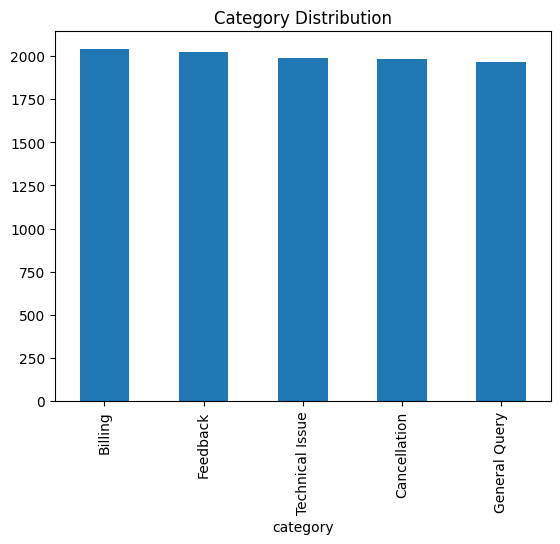

In [6]:
# Class distribution
df['category'].value_counts().plot(kind='bar', title="Category Distribution")


In [7]:
# Check for missing values
df.isnull().sum()


ticket_text    0
category       0
dtype: int64

In [8]:
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Simple text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # remove URLs
    text = re.sub(r'\@w+|\#', '', text)  # remove mentions and hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply cleaning
df['clean_text'] = df['ticket_text'].apply(clean_text)


In [9]:
df[['ticket_text', 'clean_text']].head()


,ticket_text,clean_text
0,I need a copy of my last invoice.,i need a copy of my last invoice
1,What are your working hours?,what are your working hours
2,My invoice has incorrect details.,my invoice has incorrect details
3,I need more information about your plans.,i need more information about your plans
4,My screen goes blank during login.,my screen goes blank during login


In [10]:
# Define X and y
X = df['clean_text']
y = df['category']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

                 precision    recall  f1-score   support

        Billing       1.00      1.00      1.00       408
   Cancellation       1.00      1.00      1.00       397
       Feedback       1.00      1.00      1.00       405
  General Query       1.00      1.00      1.00       393
Technical Issue       1.00      1.00      1.00       397

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000



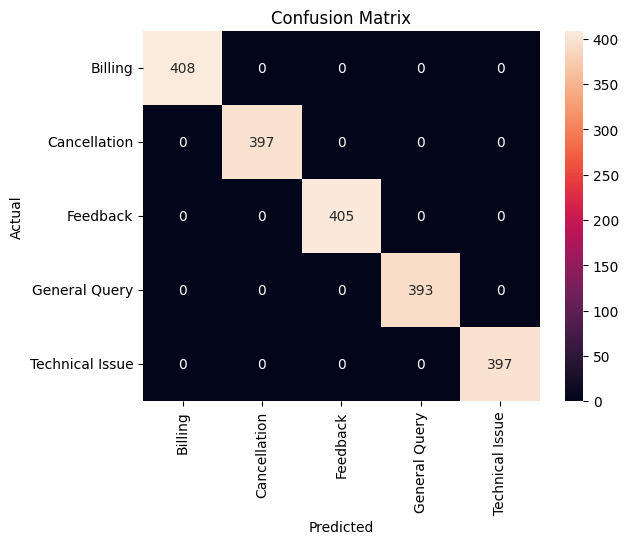

In [14]:
# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [15]:
import joblib

# Save model and vectorizer
joblib.dump(model, "../model/ticket_model.joblib")
joblib.dump(tfidf, "../model/tfidf_vectorizer.joblib")


['../model/tfidf_vectorizer.joblib']

In [16]:
pip install fastapi uvicorn joblib scikit-learn


  Using cached click-8.1.8-py3-none-any.whl (98 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'E:\Interview projects\env\Scripts\python.exe -m pip install --upgrade pip' command.
